In [1]:
import os
import warnings
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.plot import plotting_extent
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm, ListedColormap, BoundaryNorm
from matplotlib.patches import FancyArrowPatch

warnings.filterwarnings("ignore")

# =============================================================================
# 0. PATHS
# =============================================================================
carbon_folder = r"H:\7.Eco_parameter\Hunan_LULC\Revised_Carbon\Carbon_storage_correction"
trend_folder  = r"H:\7.Eco_parameter\Hunan_LULC\Revised_Carbon\Trend_Analysis"
city_shp      = r"H:\7.Eco_parameter\湖南省基础地理信息数据\湖南省及各市行政边界\430000_full.shp"

# Years for map comparison
year0 = 1990
year1 = 2023

# Density rasters
carbon_1990 = os.path.join(carbon_folder, f"CS_{year0}.tif")
carbon_2023 = os.path.join(carbon_folder, f"CS_{year1}.tif")

# Trend rasters
ts_slope_fp = os.path.join(trend_folder, "TS_slope.tif")
mk_p_fp     = os.path.join(trend_folder, "MK_pvalue.tif")
mk_z_fp     = os.path.join(trend_folder, "MK_Z.tif")

# =============================================================================
# 1. STYLE
# =============================================================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"],
    "font.size": 11,
    "axes.titlesize": 12.5,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "axes.unicode_minus": False
})

d:\Anaconda\envs\pytorch_environment\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# =============================================================================
# 2. HELPERS
# =============================================================================
def read_raster_masked(fp):
    """Read raster as masked array + metadata"""
    with rasterio.open(fp) as src:
        arr = src.read(1, masked=True).astype("float32")
        meta = {
            "transform": src.transform,
            "crs": src.crs,
            "extent": plotting_extent(src),
            "height": src.height,
            "width": src.width,
            "nodata": src.nodata,
            "res_x": abs(src.transform.a),
            "res_y": abs(src.transform.e),
        }
    return arr, meta

def ensure_same_grid(meta_ref, meta_other, name="raster"):
    """Check whether rasters are aligned"""
    assert meta_ref["crs"] == meta_other["crs"], f"CRS mismatch in {name}"
    assert meta_ref["transform"] == meta_other["transform"], f"Transform mismatch in {name}"
    assert meta_ref["height"] == meta_other["height"], f"Height mismatch in {name}"
    assert meta_ref["width"] == meta_other["width"], f"Width mismatch in {name}"

def robust_minmax(arr, lower=2, upper=98):
    """Percentile-based min/max for stable visualization"""
    vals = arr.compressed() if np.ma.isMaskedArray(arr) else arr[np.isfinite(arr)]
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return 0, 1
    return np.percentile(vals, lower), np.percentile(vals, upper)

def robust_symmetric(arr, q=98):
    """Symmetric bounds centered at 0"""
    vals = arr.compressed() if np.ma.isMaskedArray(arr) else arr[np.isfinite(arr)]
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return -1, 1
    vmax = np.percentile(np.abs(vals), q)
    return -vmax, vmax

def fix_mojibake_text(x):
    """Try to fix common shapefile Chinese mojibake"""
    if x is None:
        return x
    x = str(x)
    try:
        return x.encode("latin1").decode("utf-8")
    except Exception:
        try:
            return x.encode("latin1").decode("gbk")
        except Exception:
            return x

def mask_to_stipple_xy(mask, transform, stride=10, max_points=6000):
    """
    Convert a boolean mask to sparse stippling points for significance overlay.
    stride controls point density.
    """
    idx = np.argwhere(mask)
    if idx.size == 0:
        return np.array([]), np.array([])

    idx = idx[::stride]
    if idx.shape[0] > max_points:
        step = int(np.ceil(idx.shape[0] / max_points))
        idx = idx[::step]

    rows = idx[:, 0]
    cols = idx[:, 1]

    xs = transform.c + (cols + 0.5) * transform.a + (rows + 0.5) * transform.b
    ys = transform.f + (cols + 0.5) * transform.d + (rows + 0.5) * transform.e

    return xs, ys

# =============================================================================
# 3. READ SHAPEFILE
# =============================================================================
try:
    gdf = gpd.read_file(city_shp, encoding="utf-8")
except Exception:
    try:
        gdf = gpd.read_file(city_shp, encoding="gbk")
    except Exception:
        gdf = gpd.read_file(city_shp)

if "name" in gdf.columns:
    gdf["name"] = gdf["name"].apply(fix_mojibake_text)

# province outline from all city polygons
gdf_outline = gpd.GeoDataFrame(geometry=[gdf.unary_union], crs=gdf.crs)

# =============================================================================
# 4. READ CARBON DENSITY RASTERS
# =============================================================================
# 1990
carbon_storage_1990, meta = read_raster_masked(carbon_1990)

# 2023
carbon_storage_2023, meta1 = read_raster_masked(carbon_2023)

ensure_same_grid(meta, meta1, "carbon_storage_2023")

# Reproject shapefile to raster CRS if needed
if gdf.crs != meta["crs"]:
    gdf = gdf.to_crs(meta["crs"])
    gdf_outline = gdf_outline.to_crs(meta["crs"])

# =============================================================================
# 6. READ TREND RASTERS
# =============================================================================
ts_slope, meta_s = read_raster_masked(ts_slope_fp)
mk_p, meta_p = read_raster_masked(mk_p_fp)
mk_z, meta_z = read_raster_masked(mk_z_fp)

ensure_same_grid(meta, meta_s, "TS_slope")
ensure_same_grid(meta, meta_p, "MK_pvalue")
ensure_same_grid(meta, meta_z, "MK_Z")

# significance mask
sig_mask = (mk_p < 0.05).filled(False) if np.ma.isMaskedArray(mk_p) else (mk_p < 0.05)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.ndimage import gaussian_filter
from rasterio.transform import array_bounds

# =============================================================================
# 6. HELPERS
# =============================================================================
def get_extent(meta):
    """
    meta 为 rasterio 风格 metadata，至少包含:
    meta["height"], meta["width"], meta["transform"]
    """
    west, south, east, north = array_bounds(
        meta["height"], meta["width"], meta["transform"]
    )
    return (west, east, south, north)

def gaussian_smooth_masked(arr, sigma=1.0):
    """
    对 masked array / 含 NaN 数组做“带权平滑”，避免 nodata 污染边界。
    sigma 建议 0.6 ~ 1.2；越大越平滑。
    """
    data = np.ma.filled(arr, np.nan).astype("float32")
    valid = np.isfinite(data)

    data0 = np.where(valid, data, 0.0)
    weight = valid.astype("float32")

    data_s = gaussian_filter(data0, sigma=sigma, mode="nearest")
    weight_s = gaussian_filter(weight, sigma=sigma, mode="nearest")

    out = np.divide(
        data_s,
        weight_s,
        out=np.full_like(data_s, np.nan, dtype="float32"),
        where=weight_s > 1e-6
    )
    return np.ma.masked_invalid(out)

def draw_raster_panel(
    ax,
    arr,
    meta,
    cmap,
    gdf_city=None,
    gdf_outline=None,
    vmin=None,
    vmax=None,
    norm=None,
    panel_text=""
):
    extent = get_extent(meta)
    data = np.ma.filled(arr, np.nan)

    im = ax.imshow(
        data,
        extent=extent,
        origin="upper",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        norm=norm,
        interpolation="none",
        zorder=1
    )

    # 市界/县界（细线）
    if gdf_city is not None:
        gdf_city.boundary.plot(
            ax=ax, color="#666666", linewidth=0.25, alpha=0.55, zorder=3
        )

    # 外边界（稍粗）
    if gdf_outline is not None:
        gdf_outline.boundary.plot(
            ax=ax, color="black", linewidth=0.75, zorder=4
        )

    # 去坐标
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_facecolor("white")

    # 外框
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color("#444444")

    # 图内标签，模仿你给的示意图风格
    ax.text(
        0.03, 0.04, panel_text,
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=22, fontweight="bold", color="black",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.72, pad=1.5)
    )

    return im

total_1990_storage = gaussian_smooth_masked(carbon_storage_1990, sigma=1.0)
total_2023_storage = gaussian_smooth_masked(carbon_storage_2023, sigma=1.0)

# stack for minmax也要用碳储量平滑结果
stack_total = np.concatenate([
    np.ma.compressed(total_1990_storage),
    np.ma.compressed(total_2023_storage)
])
vmin_total, vmax_total = robust_minmax(stack_total, 2, 98)

# ---- Sen slope 也平滑，减少椒盐噪点 ----
ts_slope_storage = gaussian_smooth_masked(ts_slope, sigma=1.0)

# slope 范围：对称裁剪，避免极端值主导色带
svmin, svmax = robust_symmetric(np.ma.compressed(ts_slope_storage), q=98)

# ---- 配色 ----
seq_cmap = plt.get_cmap("viridis_r").copy()
seq_cmap.set_bad("white")

slope_cmap = plt.get_cmap("RdBu_r").copy()
slope_cmap.set_bad("white")
# slope_cmap = plt.get_cmap("coolwarm").copy()

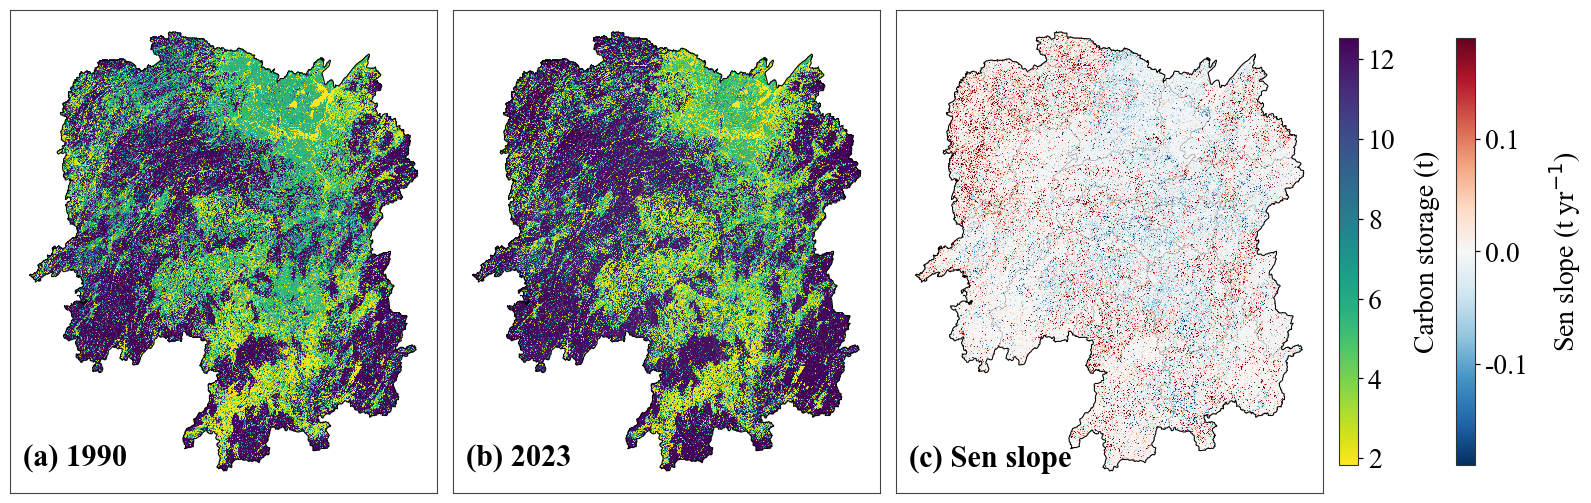

In [ ]:
# =============================================================================
# 9. FIGURE: 1 ROW × 3 COLS
# =============================================================================
# 设置全局更大的默认字体
# =============================================================================
# 5. STYLE
# =============================================================================
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    'legend.fontsize': 20,
    "figure.titlesize": 18,
    "axes.linewidth": 0.8,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
})


fig = plt.figure(figsize=(15.8, 5.3), constrained_layout=True)

# 1. 将 1 行改为 3 行，新增 height_ratios 来控制高度比例
gs = fig.add_gridspec(
    3, 5,  # 改为 3 行 5 列
    width_ratios=[1, 1, 1, 0.045, 0.045],
    height_ratios=[0.02, 0.96, 0.02],  # 上下各留白 10%，中间占 80%
    wspace=0.05
)

# 2. 主图 (ax1, ax2, ax3) 使用 gs[:, 某列]，表示跨越所有 3 行，保持原有最大尺寸
ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[:, 1])
ax3 = fig.add_subplot(gs[:, 2])

# 3. Colorbar (cax1, cax2) 使用 gs[1, 某列]，表示只放在中间那行，完美缩短到 0.8 倍并居中
cax1 = fig.add_subplot(gs[1, 3])   # shared colorbar for 1990 & 2023
cax2 = fig.add_subplot(gs[1, 4])   # colorbar for Sen slope

# ---- Panel (a): 1990 (storage) ----
im1 = draw_raster_panel(
    ax=ax1,
    arr=total_1990_storage,
    meta=meta,
    cmap=seq_cmap,
    vmin=vmin_total,
    vmax=vmax_total,
    gdf_city=gdf,
    gdf_outline=gdf_outline,
    panel_text=f"(a) {year0}"
)

# ---- Panel (b): 2023 (storage) ----
im2 = draw_raster_panel(
    ax=ax2,
    arr=total_2023_storage,
    meta=meta,
    cmap=seq_cmap,
    vmin=vmin_total,
    vmax=vmax_total,
    gdf_city=gdf,
    gdf_outline=gdf_outline,
    panel_text=f"(b) {year1}"
)

# ---- Panel (c): Sen's slope (storage) ----
im3 = draw_raster_panel(
    ax=ax3,
    arr=ts_slope_storage,
    meta=meta_s,
    cmap=slope_cmap,
    norm=TwoSlopeNorm(vmin=svmin, vcenter=0, vmax=svmax),
    gdf_city=gdf,
    gdf_outline=gdf_outline,
    panel_text="(c) Sen slope"
)

# =============================================================================
# 10. COLORBARS
# =============================================================================

# 1990 & 2023 共享色标
cb1 = fig.colorbar(im2, cax=cax1)
cb1.set_label("Carbon storage (t)", rotation=90, labelpad=13, fontsize=20)
cb1.outline.set_linewidth(0.8)
cb1.ax.tick_params(length=3.5, width=0.9, labelsize=20)

# Sen slope 色标
cb2 = fig.colorbar(im3, cax=cax2)
cb2.set_label("Sen slope (t yr$^{-1}$)", rotation=90, labelpad=13, fontsize=20)
cb2.outline.set_linewidth(0.8)
cb2.ax.tick_params(length=3.5, width=0.9, labelsize=20)

# =============================================================================
# 11. TITLE / SAVE
# =============================================================================
# fig.suptitle(
#     "Pixel-level spatial pattern of carbon storage (smoothed from density×900/1000) and its Sen's slope in Hunan",
#     fontsize=18, fontweight="bold", y=1.02
# )

plt.show()
# fig.savefig(r"H:\7.Eco_parameter\Figures\修正后的碳储量空间分布\Fig_storage_sen_slope_1x3.png")

尝试编码 gb18030：匹配到 0 个城市
尝试编码 gbk：匹配到 0 个城市
尝试编码 cp936：匹配到 0 个城市
尝试编码 utf-8：匹配到 14 个城市

最终采用编码：utf-8（匹配 14 个城市）

SHP 城市名预览：
['长沙市', '株洲市', '湘潭市', '衡阳市', '邵阳市', '岳阳市', '常德市', '张家界市', '益阳市', '郴州市', '永州市', '怀化市', '娄底市', '湘西土家族苗族自治州']
Projected CRS: EPSG:32649

仍未匹配到碳储量数据的城市：
[]


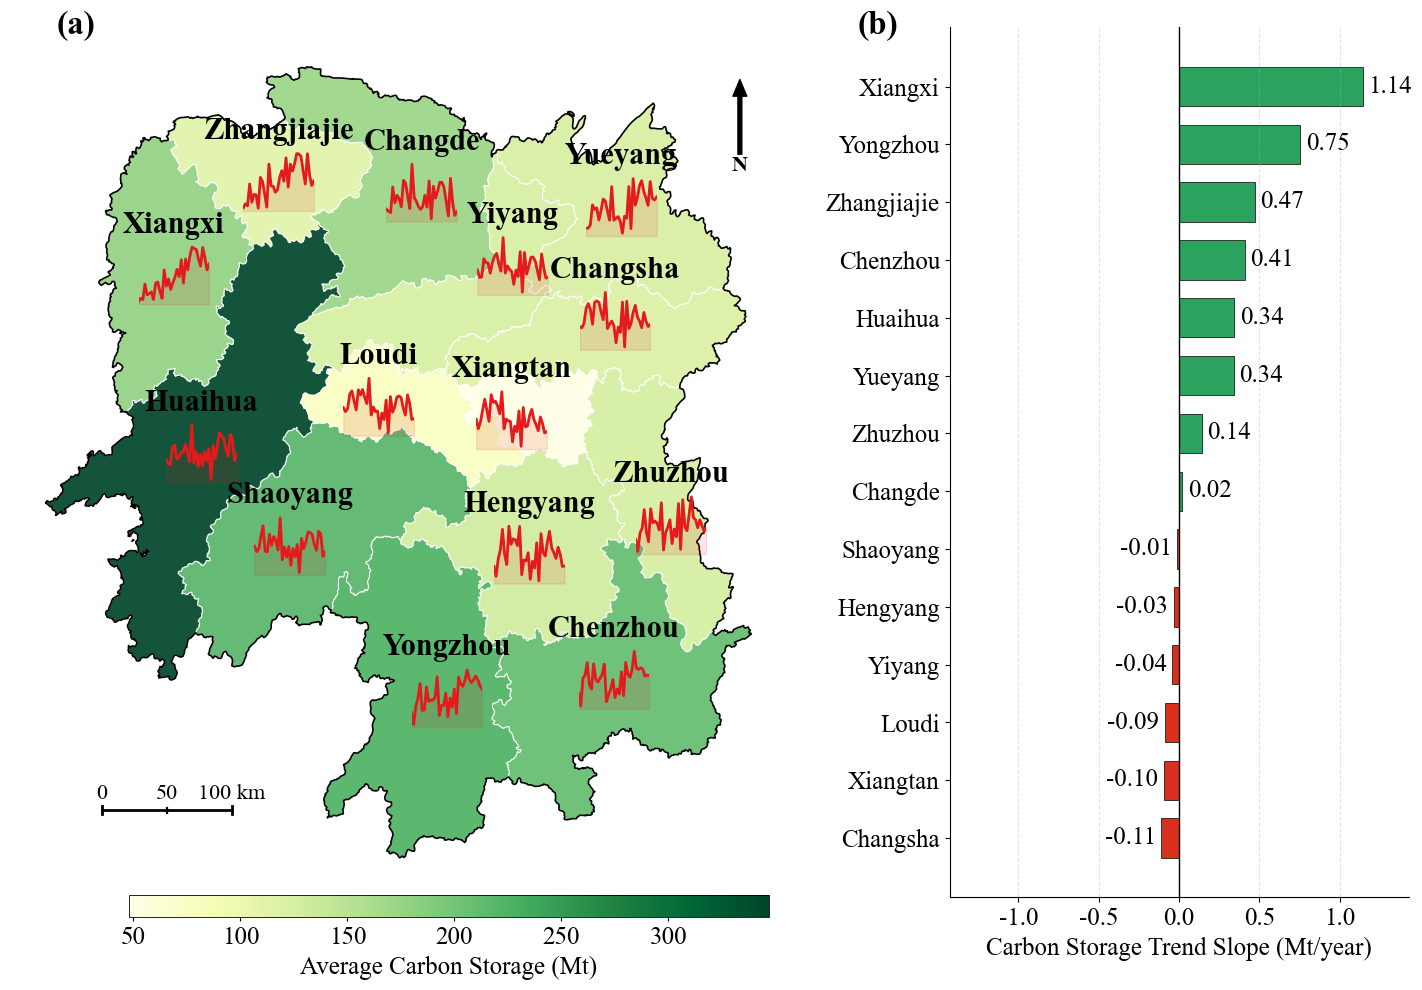

In [ ]:
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ==========================================
# 1. 路径与参数
# ==========================================
csv_path = r"H:\7.Eco_parameter\Hunan_LULC\Revised_Carbon\city_annual_total_stock_wide.csv"
shp_path = r"H:\7.Eco_parameter\湖南省基础地理信息数据\湖南省及各市行政边界\430000_full.shp"
out_path = r"H:\7.Eco_parameter\Figures\修正后的碳储量时间分布\Hunan_city_carbon_storage_map_bar.png"

shp_city_col = "name"   # 这里核对你的字段名

city_name_map = {
    "怀化市": "Huaihua",
    "邵阳市": "Shaoyang",
    "郴州市": "Chenzhou",
    "永州市": "Yongzhou",
    "湘西土家族苗族自治州": "Xiangxi",
    "张家界市": "Zhangjiajie",
    "常德市": "Changde",
    "益阳市": "Yiyang",
    "娄底市": "Loudi",
    "岳阳市": "Yueyang",
    "长沙市": "Changsha",
    "衡阳市": "Hengyang",
    "湘潭市": "Xiangtan",
    "株洲市": "Zhuzhou"
}

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.unicode_minus"] = False

# ==========================================
# 2. 自动尝试正确编码读取 shp
# ==========================================
def read_shp_with_best_encoding(shp_path, shp_city_col, expected_cities):
    encodings = ["gb18030", "gbk", "cp936", "utf-8"]
    best_gdf = None
    best_enc = None
    best_overlap = -1

    for enc in encodings:
        try:
            gdf_try = gpd.read_file(shp_path, encoding=enc, engine="fiona")
            gdf_try.columns = gdf_try.columns.str.strip()

            if shp_city_col not in gdf_try.columns:
                print(f"[{enc}] 未找到字段 {shp_city_col}，现有字段：{list(gdf_try.columns)}")
                continue

            names = gdf_try[shp_city_col].astype(str).str.strip().tolist()
            overlap = sum([1 for x in names if x in expected_cities])
            print(f"尝试编码 {enc}：匹配到 {overlap} 个城市")

            if overlap > best_overlap:
                best_overlap = overlap
                best_enc = enc
                best_gdf = gdf_try

        except Exception as e:
            print(f"尝试编码 {enc} 失败：{e}")

    if best_gdf is None:
        raise ValueError("所有编码均读取失败，请检查 shp / dbf / cpg 文件是否完整。")

    print(f"\n最终采用编码：{best_enc}（匹配 {best_overlap} 个城市）")
    return best_gdf

# ==========================================
# 3. 读取 CSV
# ==========================================
df_raw = pd.read_csv(csv_path)
df_raw.columns = df_raw.columns.str.strip()

# ==========================================
# 4. 读取 shp（自动选最佳编码）
# ==========================================
expected_cities = set(city_name_map.keys())
gdf = read_shp_with_best_encoding(shp_path, shp_city_col, expected_cities)

gdf[shp_city_col] = gdf[shp_city_col].astype(str).str.strip()

print("\nSHP 城市名预览：")
print(gdf[shp_city_col].tolist())

# ==========================================
# 5. 自动识别宽表/长表，并整理成长表
#    目标列：city, year, stock_TgC_total
# ==========================================
if {"city", "year", "stock_TgC_total"}.issubset(df_raw.columns):
    df = df_raw.copy()
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df["stock_TgC_total"] = pd.to_numeric(df["stock_TgC_total"], errors="coerce")
else:
    year_cols = [c for c in df_raw.columns if re.fullmatch(r"\d{4}", str(c))]
    if len(year_cols) == 0:
        raise ValueError("未识别到宽表年份列，请检查 CSV 格式。")

    if "city" not in df_raw.columns:
        raise ValueError("CSV 中未找到 city 列。")

    df = df_raw.melt(
        id_vars="city",
        value_vars=year_cols,
        var_name="year",
        value_name="stock_TgC_total"
    )
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df["stock_TgC_total"] = pd.to_numeric(df["stock_TgC_total"], errors="coerce")

df = df.dropna(subset=["city", "year", "stock_TgC_total"]).copy()
df["city"] = df["city"].astype(str).str.strip()

# ==========================================
# 6. 计算多年平均碳储量（底图）与净变化量（右侧条形图）
# ==========================================
# 6.1 多年平均值
df_avg = (
    df.groupby("city", as_index=False)["stock_TgC_total"]
      .mean()
      .rename(columns={"stock_TgC_total": "stock_avg"})
)

# 6.2 净变化量改为拟合曲线的斜率
from scipy.stats import linregress

# 保证数据完整、无缺失
df_valid = df.dropna(subset=["city", "year", "stock_TgC_total"]).copy()

city_net_changes = []
for city, group in df_valid.groupby("city"):
    x = group["year"].values
    y = group["stock_TgC_total"].values
    if len(x) >= 2:
        reg = linregress(x, y)
        net_change = reg.slope
    else:
        net_change = np.nan
    city_net_changes.append({
        "city": city,
        "net_change": net_change
    })

df_net = pd.DataFrame(city_net_changes).dropna(subset=["net_change"]).copy()
df_net["city_en"] = df_net["city"].map(city_name_map).fillna(df_net["city"])

# 按斜率从大到小排序，为右侧条形图配色
bar_df = df_net.sort_values("net_change", ascending=False).copy()
bar_df["bar_color"] = np.where(bar_df["net_change"] >= 0, "#2ca25f", "#d7301f")

# ==========================================
# 7. 合并到矢量数据并重投影
# ==========================================
gdf_plot = gdf.merge(df_avg, left_on=shp_city_col, right_on="city", how="left")

# 重投影到适合湖南的米制坐标系（用于比例尺）
utm_crs = gdf_plot.estimate_utm_crs()
print("Projected CRS:", utm_crs)
gdf_plot = gdf_plot.to_crs(utm_crs)

province_outline = gdf_plot.dissolve()

missing_cities = gdf_plot[gdf_plot["stock_avg"].isna()][shp_city_col].tolist()
print("\n仍未匹配到碳储量数据的城市：")
print(missing_cities)

# ==========================================
# 8. 创建图幅：左图地图 + 右图条形图
# ==========================================
fig = plt.figure(figsize=(16, 10), facecolor="white")
gs = fig.add_gridspec(
    1, 2,
    width_ratios=[2.15, 1.0],
    left=0.04, right=0.98, top=0.97, bottom=0.10,
    wspace=0.08
)

ax_map = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1])

# 在左右图左上角分别加上 (a) (b)
ax_map.text(
    0.06, 1.02, "(a)", transform=ax_map.transAxes,
    fontsize=24, fontweight="bold", va="top", ha="left"
)
ax_bar.text(
    -0.2, 1.02, "(b)", transform=ax_bar.transAxes,
    fontsize=24, fontweight="bold", va="top", ha="left"
)

# ==========================================
# 9. 左侧地图
# ==========================================
cmap = plt.cm.YlGn
vmin = gdf_plot["stock_avg"].min()
vmax = gdf_plot["stock_avg"].max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

gdf_plot.plot(
    column="stock_avg",
    cmap=cmap,
    linewidth=0.8,
    edgecolor="white",
    ax=ax_map,
    alpha=0.92,
    legend=False,
    missing_kwds={"color": "#f0f0f0", "label": "No data"}
)

province_outline.boundary.plot(ax=ax_map, color="black", linewidth=1.2)
ax_map.set_axis_off()

# ==========================================
# 10. 地图中的各城市 inset 折线图
# ==========================================
bounds = gdf_plot.total_bounds
map_width = bounds[2] - bounds[0]
map_height = bounds[3] - bounds[1]

# 因为右边加了条形图，左图相对变窄，这里稍微缩小 inset
inset_width = map_width * 0.1
inset_height = map_height * 0.08

offsets = {
    "长沙市": (0.00 * map_width,  0.018 * map_height),
    "株洲市": (0.020 * map_width, -0.018 * map_height),
    "湘潭市": (-0.022 * map_width, -0.006 * map_height),
    "衡阳市": (0.010 * map_width, -0.008 * map_height),
    "娄底市": (-0.012 * map_width, 0.010 * map_height),
}

for idx, row in gdf_plot.iterrows():
    city_zh = row[shp_city_col]
    city_data = df[df["city"] == city_zh].sort_values("year")
    if city_data.empty:
        continue

    pt = row.geometry.representative_point()
    x, y = pt.x, pt.y

    dx, dy = offsets.get(city_zh, (0, 0))
    x += dx
    y += dy

    ax_inset = ax_map.inset_axes(
        [x - inset_width / 2, y - inset_height / 2, inset_width, inset_height],
        transform=ax_map.transData
    )

    ax_inset.plot(
        city_data["year"],
        city_data["stock_TgC_total"],
        color="#e41a1c",
        linewidth=2.0
    )

    ymin = city_data["stock_TgC_total"].min()
    ymax = city_data["stock_TgC_total"].max()
    yrange = ymax - ymin if ymax > ymin else 1.0

    ax_inset.fill_between(
        city_data["year"],
        city_data["stock_TgC_total"],
        ymin - 0.05 * yrange,
        color="#e41a1c",
        alpha=0.12
    )

    ax_inset.set_xlim(df["year"].min(), df["year"].max())
    ax_inset.set_ylim(ymin - 0.08 * yrange, ymax + 0.08 * yrange)
    ax_inset.set_axis_off()
    ax_inset.patch.set_alpha(0)

    city_en = city_name_map.get(city_zh, city_zh)
    ax_inset.text(
        0.5, 1.05, city_en,
        transform=ax_inset.transAxes,
        ha="center", va="bottom",
        fontsize=22,
        fontweight="bold",
        color="black"
    )

# ==========================================
# 11. 指北针
# ==========================================
ax_map.annotate(
    "N",
    xy=(0.94, 0.94), xytext=(0.94, 0.84),
    arrowprops=dict(
        facecolor="black",
        edgecolor="black",
        width=2.8,
        headwidth=10,
        headlength=12
    ),
    ha="center", va="center",
    fontsize=16, fontweight="bold",
    xycoords=ax_map.transAxes
)

# ==========================================
# 12. 比例尺（100 km）
# ==========================================
xmin, ymin, xmax, ymax = gdf_plot.total_bounds

scalebar_length = 100000  # 100 km
x0 = xmin + 0.08 * (xmax - xmin)
y0 = ymin + 0.06 * (ymax - ymin)
tick_h = 0.010 * (ymax - ymin)

# 主线
ax_map.plot([x0, x0 + scalebar_length], [y0, y0], color="black", linewidth=2)

# 两端竖线
ax_map.plot([x0, x0], [y0 - tick_h / 2, y0 + tick_h / 2], color="black", linewidth=2)
ax_map.plot(
    [x0 + scalebar_length, x0 + scalebar_length],
    [y0 - tick_h / 2, y0 + tick_h / 2],
    color="black", linewidth=2
)

# 中间刻度
ax_map.plot(
    [x0 + scalebar_length / 2, x0 + scalebar_length / 2],
    [y0 - tick_h / 3, y0 + tick_h / 3],
    color="black", linewidth=1.6
)

# 标签
ax_map.text(x0, y0 + tick_h * 0.8, "0", ha="center", va="bottom", fontsize=16)
ax_map.text(x0 + scalebar_length / 2, y0 + tick_h * 0.8, "50", ha="center", va="bottom", fontsize=16)
ax_map.text(x0 + scalebar_length, y0 + tick_h * 0.8, "100 km", ha="center", va="bottom", fontsize=16)

# ==========================================
# 13. 底图 colorbar（放在左下侧外部）
# ==========================================
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cax = fig.add_axes([0.18, 0.08, 0.4, 0.022])   # [left, bottom, width, height]
cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
cb.ax.tick_params(labelsize=18, length=3)
cb.outline.set_linewidth(0.6)
cb.set_label("Average Carbon Storage (Mt)", fontsize=18)

# ==========================================
# 14. 右侧净变化量排序条形图（斜率）
# ==========================================
ypos = np.arange(len(bar_df))

ax_bar.barh(
    ypos,
    bar_df["net_change"],
    color=bar_df["bar_color"],
    edgecolor="black",
    linewidth=0.5,
    height=0.68
)

ax_bar.set_yticks(ypos)
ax_bar.set_yticklabels(bar_df["city_en"], fontsize=18)
ax_bar.invert_yaxis()  # 最大值放在最上方

ax_bar.axvline(0, color="black", linewidth=1.0)
ax_bar.grid(axis="x", linestyle="--", alpha=0.35)

ax_bar.set_xlabel("Carbon Storage Trend Slope (Mt/year)", fontsize=18)
# ax_bar.set_title("City ranking by slope", fontsize=18, pad=10)

# x轴范围留白
max_abs = np.nanmax(np.abs(bar_df["net_change"]))
ax_bar.set_xlim(-max_abs * 1.25, max_abs * 1.25)
ax_bar.tick_params(axis='x', labelsize=18)

# 数值标注
offset = max_abs * 0.03
for i, value in enumerate(bar_df["net_change"]):
    if value >= 0:
        ax_bar.text(value + offset, i, f"{value:.2f}", va="center", ha="left", fontsize=18)
    else:
        ax_bar.text(value - offset, i, f"{value:.2f}", va="center", ha="right", fontsize=18)

# 去掉多余边框
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)

# # 说明颜色含义
# ax_bar.text(
#     0.02, 0.02,
#     "Green: increase\nRed: decrease",
#     transform=ax_bar.transAxes,
#     ha="left", va="bottom",
#     fontsize=14
# )

# ==========================================
# 15. 保存与显示
# ==========================================
# plt.savefig(out_path, dpi=600, bbox_inches="tight")
plt.show()

# print(f"\n图件已保存至：{out_path}")

In [15]:
import rasterio
import numpy as np

soil_c_path = r"H:\7.Eco_parameter\Hunan_LULC\Revised_Carbon\Carbon_Density_correction\C_soil_2023.tif"
lc_path = r"H:\7.Eco_parameter\Hunan_LULC\LULC_result\annual_LC_from_1\LC_from_1_2023.tif"

# 尝试读取土壤碳密度数据，捕获读取错误
try:
    with rasterio.open(soil_c_path) as src_c:
        c_density = src_c.read(1).astype(np.float32)
        c_density[c_density == src_c.nodata] = np.nan
except Exception as e:
    print(f"读取土壤碳密度栅格失败: {e}")
    c_density = None

# 读取LC数据，确保结果可设置为float（以便支持np.nan），否则强转为float
try:
    with rasterio.open(lc_path) as src_lc:
        lc = src_lc.read(1)
        # 确保为float类型或能安全转为float
        if not np.issubdtype(lc.dtype, np.floating):
            lc = lc.astype(np.float32)
        lc[lc == src_lc.nodata] = np.nan
except Exception as e:
    print("读取LC栅格失败: cannot convert float NaN to integer")
    lc = None

# 检查两者都成功再继续
if c_density is not None and lc is not None:
    mask_forest = (lc == 2)
    # 计算森林土壤碳储量，碳储量=碳密度*900/10000
    soil_c_forest = c_density[mask_forest] * 900 / 10000
    # 总和（单位: TgC）
    total_soil_c_forest = np.nansum(soil_c_forest)
    print(f"2023年湖南省森林土壤碳储量总和为: {total_soil_c_forest:.2f} TgC")
else:
    print("无法完成计算，因为栅格读取失败。")

2023年湖南省森林土壤碳储量总和为: 1334747520.00 TgC


In [16]:
total_soil_c_forest/1000000

1334.74752

In [11]:
df_density = pd.read_csv(r"H:\7.Eco_parameter\Hunan_LULC\Revised_Carbon\city_carbon_density_zonal_fast.csv")
city_density = df_density.groupby("city", as_index=False)["total"].mean()
print("逐城市34年碳密度平均值（t/hm2）：")
print(city_density.sort_values("total", ascending=False).reset_index(drop=True))

逐城市34年碳密度平均值（t/hm2）：
          city       total
0          怀化市  111.188894
1         张家界市  102.562379
2   湘西土家族苗族自治州  101.144887
3          株洲市   99.750617
4          郴州市   97.522906
5          邵阳市   93.353985
6          长沙市   90.879084
7          永州市   90.776298
8          益阳市   89.112846
9          娄底市   84.528638
10         湘潭市   84.103453
11         常德市   83.023047
12         衡阳市   75.544652
13         岳阳市   72.645583


In [10]:
import pandas as pd

# 读取城市逐年碳储量数据（已为长表，含 ['city', 'year', 'stock_TgC_total'] 三列）
df = pd.read_csv(r"H:\7.Eco_parameter\Hunan_LULC\Revised_Carbon\city_annual_total_stock_wide.csv")

# 按年份汇总全省碳储量（TgC）
annual_total = df.groupby('city')['stock_TgC_total'].mean()

print("逐城市34年碳储量平均值（TgC）：")
print(annual_total.sort_values(ascending=False))

逐城市34年碳储量平均值（TgC）：
city
怀化市           346.859412
永州市           225.706765
邵阳市           218.881765
郴州市           210.205882
湘西土家族苗族自治州    179.324118
常德市           173.878235
衡阳市           130.058824
株洲市           126.796176
益阳市           125.606471
岳阳市           124.067647
长沙市           122.357059
张家界市          112.672059
娄底市            77.779706
湘潭市            47.826176
Name: stock_TgC_total, dtype: float64


In [9]:
import pandas as pd

# 读取城市逐年碳储量数据（已为长表，含 ['city', 'year', 'stock_TgC_total'] 三列）
df = pd.read_csv(r"H:\7.Eco_parameter\Hunan_LULC\Revised_Carbon\city_annual_total_stock_wide.csv")

# 按年份汇总全省碳储量（TgC）
annual_total = df.groupby('year')['stock_TgC_total'].sum()

print("逐年全省碳储量总和（TgC）：")
print(annual_total)

逐年全省碳储量总和（TgC）：
year
1990    2122.74
1991    2080.63
1992    2139.50
1993    2246.83
1994    2274.64
1995    2178.72
1996    2146.92
1997    2251.12
1998    2247.52
1999    2263.76
2000    2219.29
2001    2170.81
2002    2395.56
2003    2115.45
2004    2179.68
2005    2148.07
2006    2194.27
2007    2093.44
2008    2201.04
2009    2142.59
2010    2306.90
2011    2055.17
2012    2339.94
2013    2223.56
2014    2263.82
2015    2344.52
2016    2381.49
2017    2320.63
2018    2262.11
2019    2216.46
2020    2346.61
2021    2275.64
2022    2189.28
2023    2209.98
Name: stock_TgC_total, dtype: float64


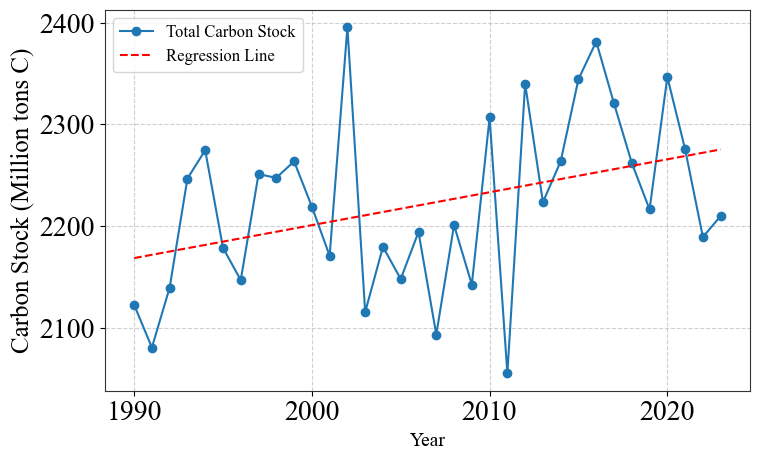

回归直线的斜率为: 3.2380 TgC/year


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Line plot (English version)
plt.figure(figsize=(8, 5))
plt.plot(annual_total.index, annual_total.values, marker='o', linestyle='-', label='Total Carbon Stock')

# Fit regression line and calculate slope
z = np.polyfit(annual_total.index.astype(float), annual_total.values, 1)
slope = z[0]
p = np.poly1d(z)
plt.plot(annual_total.index, p(annual_total.index.astype(float)), "r--", label='Regression Line')

plt.xlabel('Year', fontsize=14)
plt.ylabel('Carbon Stock (Million tons C)', fontsize=18)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"回归直线的斜率为: {slope:.4f} TgC/year")

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import rasterio

# 文件夹路径
carbon_density_dir = r"H:\7.Eco_parameter\Hunan_LULC\Revised_Carbon\Carbon_Density_correction"
lulc_dir = r"H:\7.Eco_parameter\Hunan_LULC\LULC_result\annual_LC_from_1"

# 输出保存路径
output_dir = r"D:\Desktop\Tsinghua\论文\MTUTC-1th-JCP\Results"
os.makedirs(output_dir, exist_ok=True)

results = []

# Pool类型映射
pool_map = {
    "c_above": "above",
    "c_below": "below",
    "c_dead": "dead",
    "c_soil": "soil",
    "c_total": "total"
}

# 匹配碳密度tif文件
density_files = glob.glob(os.path.join(carbon_density_dir, "*.tif"))

for density_fp in density_files:
    # 假设文件命名为 C_POOL_YYYY.tif
    basename = os.path.basename(density_fp)
    try:
        pool_str, year_str = basename.rsplit("_", 1)
        pool_type = pool_map.get(pool_str.lower(), None)
        if pool_type is None:
            continue
        year = int(year_str.replace('.tif', ''))
    except:
        continue

    # 对应的LULC栅格文件
    lulc_fp = os.path.join(lulc_dir, f"LC_from_1_{year}.tif")
    if not os.path.exists(lulc_fp):
        continue

    # 读取数据
    with rasterio.open(density_fp) as src:
        density = src.read(1).astype(float)
        mask = src.read_masks(1) > 0

    with rasterio.open(lulc_fp) as lulc_src:
        lulc = lulc_src.read(1)

    # 查找森林像元（陆地覆盖类型==2）
    forest_mask = (lulc == 2) & mask & (~np.isnan(density))

    if np.sum(forest_mask) == 0:
        continue

    forest_density = density[forest_mask]
    # 平均碳密度
    mean_density = np.nanmean(forest_density)
    # 总碳储量 = 每像元密度*像元面积后求和
    pixel_area_m2 = 30 * 30  # 900 m²
    pixel_area_hm2 = pixel_area_m2 / 10000  # 单位换算为 hm²
    total_storage = np.nansum(forest_density * pixel_area_hm2)  # 单位:tC

    results.append({
        "year": year,
        "pool": pool_type,
        "density_pool": mean_density,
        "storage_pool": total_storage
    })

df_result = pd.DataFrame(results)

required_cols = set(['pool', 'year'])
missing_cols = required_cols - set(df_result.columns)
if missing_cols:
    print(f"警告：DataFrame中缺失以下列，未进行排序: {missing_cols}")
else:
    df_result = df_result.sort_values(['pool', 'year'])

output_csv = os.path.join(output_dir, "forest_carbon_density_and_storage_per_pool_per_year.csv")
df_result.to_csv(output_csv, index=False)
print("结果已保存到: D:\\Desktop\\Tsinghua\\论文\\MTUTC-1th-JCP\\Results\\forest_carbon_density_and_storage_per_pool_per_year.csv")

d:\Anaconda\envs\pytorch_environment\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


结果已保存到: D:\Desktop\Tsinghua\论文\MTUTC-1th-JCP\Results\forest_carbon_density_and_storage_per_pool_per_year.csv


In [10]:
# 这组找min max
data = [
    30.30999947,
    29.16494227,
    29.25863968,
    30.51091002,
    31.19136295,
    29.90346912,
    29.33249352,
    30.77616917,
    31.0093658,
    30.83350794,
    30.11435454,
    29.52847101,
    32.52827888,
    28.81996704,
    30.00760864,
    29.27595913,
    30.34501223,
    28.86782052,
    29.84082653,
    29.01798697,
    30.87065455,
    27.00598167,
    30.78898607,
    29.41238373,
    30.00877696,
    31.03952128,
    31.61029417,
    30.8553974,
    30.26544104,
    29.50191556,
    31.38597387,
    30.80094175,
    29.76358413,
    30.29684089
]

min_val = min(data)
max_val = max(data)
print("min值：", min_val)
print("max值：", max_val)


min值： 27.00598167
max值： 32.52827888
